# Importing libraries

In [366]:
import pandas as pd
import numpy as np
from pathlib import Path
from functools import reduce
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.api.types import CategoricalDtype

In [2]:
pd.set_option('display.max_columns', None)

# Importing datasets

In [3]:
# Checking path validity
path = "../../../Dta raw files/level_01.dta"
print(Path(path).resolve())
print(Path(path).exists())

G:\My Drive\KG TM - Joint projects\HCES\HCES 2022-23\Dta raw files\level_01.dta
True


In [259]:
# Reading HH-wise mpce
path_mpce = "../Population based MPCE/MPCE_1Jan24.pkl"
df_mpce = pd.read_pickle(path_mpce)
df_mpce = df_mpce[['total expenditure', 'hh_size', 'sector', 'multiplier', 'mpce', 'decile']]
#display(df_mpce.head())
print(df_mpce.shape, "\n", '-'*40)

# Level-01: Geographical identifiers
path_lvl01 = "../../../Dta raw files/level_01.dta"
df_lvl01 = pd.read_stata(path_lvl01)
df_lvl01 = df_lvl01.set_index('hhid')
df_lvl01 = df_lvl01[['state', 'nss_region', 'district']]
#display(df_lvl01.head())
print(df_lvl01.shape, "\n", "-"*40)

# Level-03: Socio-economic status
path_lvl03 = "../../../Dta raw files/level_03.dta"
df_lvl03 = pd.read_stata(path_lvl03)
df_lvl03 = df_lvl03.set_index('hhid')
df_lvl03 = df_lvl03[['employed_annual', 'num_activities_income', 'hasincome_selfemp_agri',
                    'hasincome_wage_agri', 'hasincome_casual_agri', 'hh_type','hoh_religion', 'caste',
                    'has_land', 'land_type','land_area', 'has_house', 'type_house', 'material_wall',
                    'material_roof', 'material_floor', 'type_rationcard', 'has_pmgky'
                     ]]
#display(df_lvl03.head())
print(df_lvl03.shape, "\n", "-"*40)

# Level-04: PMGKY benefits
path_lvl04 = "../../../Dta raw files/level_04.dta"
df_lvl04 = pd.read_stata(path_lvl04)
df_lvl04 = df_lvl04.set_index('hhid')
df_lvl04 = df_lvl04[['used_ration']]
#display(df_lvl04.head())
print(df_lvl04.shape, "\n", "-"*40)

# Level-06: Processed food consumption
path_lvl06 = "../../../Dta raw files/level_06.dta"
df_lvl06 = pd.read_stata(path_lvl06)
df_lvl06['item_code'] = df_lvl06['item_code'].astype(str).str.zfill(3) 
df_lvl06 = df_lvl06.loc[df_lvl06['item_code'].isin(['289', '299'])]
df_lvl06 = df_lvl06.pivot(index = 'hhid', columns = 'item_code', values = 'cons_total_value')
df_lvl06.columns.name = None
df_lvl06 = df_lvl06.rename({'289': 'cons_served_processed', '299': 'cons_packaged_processed'}, axis = 1)
#display(df_lvl06.head())
print(df_lvl06.shape, "\n", "-"*40)

# Level-07: PMJAY benefits
path_lvl07 = "../../../Dta raw files/level_07.dta"
df_lvl07 = pd.read_stata(path_lvl07)
df_lvl07 = df_lvl07.set_index('hhid')
df_lvl07 = df_lvl07[['is_hhmem_pmjay', 'is_benefit_healthscheme']]
#display(df_lvl07.head())
print(df_lvl07.shape, "\n", "-"*40)
# Note: Nan is for HHs that didn't see any hospitalisation in the last 365 days

# Level-08: Cooking fuel consumption
path_lvl08 = "../../../Dta raw files/level_08.dta"
df_lvl08 = pd.read_stata(path_lvl08)
df_lvl08['item_code'] = df_lvl08['item_code'].astype(str).str.zfill(3) 
df_lvl08 = df_lvl08.loc[df_lvl08['item_code'].isin(['332', '338', '331', '334', '335', '096', '349'])]
df_lvl08 = df_lvl08.pivot(index = 'hhid', columns = 'item_code', values = 'cons_total_value')
df_lvl08.columns.name = None
df_lvl08 = df_lvl08.rename({'332': 'fuel_elec', '338': 'fuel_lpg',
                            '331': 'fuel_firewood', '334': 'fuel_kerosenePDS',
                            '335': 'fuel_keroseneother', '096': 'fuel_other',
                            '349': 'fuel_total'}, axis = 1)
#display(df_lvl08.head())
print(df_lvl08.shape, "\n", "-"*40)

# Level-11: Asset ownership
path_lvl11 = "../../../Dta raw files/level_11.dta"
df_lvl11 = pd.read_stata(path_lvl11)
df_lvl11 = df_lvl11.set_index('hhid')
df_lvl11 = df_lvl11[['has_tv', 'has_radio', 'has_laptop', 'has_mobile', 'has_bicycle', 'has_bike', 'has_car', 'has_truck', 'has_animalcart', 'has_fridge', 'has_washingmachine', 'has_ac']]
df_lvl11 = df_lvl11.rename({'has_ac': 'has_acORcooler'}, axis = 1)
#display(df_lvl11.head())
print(df_lvl11.shape, "\n", "-"*40)

(261746, 6) 
 ----------------------------------------
(261746, 3) 
 ----------------------------------------
(261746, 18) 
 ----------------------------------------
(261746, 1) 
 ----------------------------------------
(257084, 2) 
 ----------------------------------------
(261746, 2) 
 ----------------------------------------
(261313, 7) 
 ----------------------------------------
(261746, 12) 
 ----------------------------------------


# Merging dataframes

In [260]:
# Function to merge dataframes based on index
def merge_dataframe(df1,df2):
    new_df = pd.merge(df1, df2, how = 'outer', left_index=True, right_index=True, indicator = True)
    display(new_df['_merge'].value_counts())
    new_df = new_df.drop(labels = '_merge', axis = 1)
    return new_df.copy()

# Merging dataframes
trial = reduce(merge_dataframe, [df_lvl01, df_lvl03, df_lvl04, df_lvl06,df_lvl07, df_lvl08, df_lvl11, df_mpce])

_merge
both          261746
left_only          0
right_only         0
Name: count, dtype: int64

_merge
both          261746
left_only          0
right_only         0
Name: count, dtype: int64

_merge
both          257084
left_only       4662
right_only         0
Name: count, dtype: int64

_merge
both          261746
left_only          0
right_only         0
Name: count, dtype: int64

_merge
both          261313
left_only        433
right_only         0
Name: count, dtype: int64

_merge
both          261746
left_only          0
right_only         0
Name: count, dtype: int64

_merge
both          261746
left_only          0
right_only         0
Name: count, dtype: int64

In [261]:
trial.head()

,state,nss_region,district,employed_annual,num_activities_income,hasincome_selfemp_agri,hasincome_wage_agri,hasincome_casual_agri,hh_type,hoh_religion,caste,has_land,land_type,land_area,has_house,type_house,material_wall,material_roof,material_floor,type_rationcard,has_pmgky,used_ration,cons_served_processed,cons_packaged_processed,is_hhmem_pmjay,is_benefit_healthscheme,fuel_other,fuel_firewood,fuel_elec,fuel_kerosenePDS,fuel_keroseneother,fuel_lpg,fuel_total,has_tv,has_radio,has_laptop,has_mobile,has_bicycle,has_bike,has_car,has_truck,has_animalcart,has_fridge,has_washingmachine,has_acORcooler,total expenditure,hh_size,sector,multiplier,mpce,decile
hhid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
31000301,28,283,12,1,2.0,NaN,NaN,NaN,2,1,3,1,1.0,0.01,1,2.0,6.0,7.0,6.0,0,2,2,1500.0,15.0,2,NaN,27.0,NaN,80.0,NaN,NaN,240.0,347.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19675.64,1.0,2,96498,19675.64,10
31000302,28,283,12,1,2.0,NaN,NaN,NaN,2,1,3,1,1.0,0.02,1,2.0,6.0,8.0,6.0,4,1,1,1450.0,70.0,1,NaN,23.0,NaN,452.0,NaN,NaN,640.0,1115.0,1.0,NaN,NaN,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,40297.61,5.0,2,96498,8059.52,8
31000303,28,283,12,1,2.0,NaN,NaN,NaN,2,1,3,1,1.0,0.03,1,2.0,6.0,8.0,6.0,4,1,1,150.0,130.0,1,NaN,27.0,NaN,482.0,NaN,NaN,720.0,1229.0,1.0,NaN,NaN,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,38140.10,5.0,2,96498,7628.02,8
31000304,28,283,12,1,1.0,NaN,NaN,NaN,1,1,3,1,1.0,0.03,1,1.0,6.0,7.0,6.0,4,1,1,150.0,25.0,1,NaN,28.0,NaN,342.0,NaN,NaN,400.0,770.0,1.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,13045.25,2.0,2,96498,6522.62,7
31000305,28,283,12,2,NaN,NaN,NaN,NaN,9,1,3,1,1.0,0.03,1,1.0,6.0,8.0,6.0,4,1,1,NaN,NaN,1,NaN,17.0,NaN,328.0,NaN,NaN,320.0,665.0,1.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,6765.77,1.0,2,96498,6765.77,7


# Handling missing values

In [364]:
# Copy of merged df
df = trial.copy()


# Changing dtype and padding zeroes

## Strings of size 1
col_name_1 = ['employed_annual', 'num_activities_income', 'hasincome_selfemp_agri', 'hasincome_wage_agri', 
              'hasincome_casual_agri', 'hh_type', 'hoh_religion', 'caste', 'has_land', 'land_type',
              'has_house', 'type_house', 'material_wall', 'material_roof', 'material_floor', 'type_rationcard',
              'has_pmgky', 'used_ration', 'is_hhmem_pmjay', 'is_benefit_healthscheme', 'has_tv', 'has_radio', 
              'has_laptop', 'has_mobile', 'has_bicycle', 'has_bike', 'has_car', 'has_truck', 'has_animalcart', 
              'has_fridge', 'has_washingmachine', 'has_acORcooler', 'sector', 'decile']
df[col_name_1] = df[col_name_1].apply(lambda col: pd.to_numeric(col, errors = 'coerce').round())
df[col_name_1] = df[col_name_1].astype('Int64')
df[col_name_1] = df[col_name_1].apply(lambda col: col[pd.notnull(col)].astype(str), axis = 0)

## Strings of size 2
col_name_2 = ['state', 'district']
df[col_name_2] = df[col_name_2].apply(lambda col: pd.to_numeric(col, errors = 'coerce').round())
df[col_name_2] = df[col_name_2].astype('Int64')
df[col_name_2] = df[col_name_2].apply(lambda col: col[pd.notnull(col)].astype(str), axis = 0)
df[col_name_2] = df[col_name_2].apply(lambda col: col.str.zfill(2), axis = 0)

## Strings of size 3
col_name_3 = ['nss_region']
df[col_name_3] = df[col_name_3].apply(lambda col: pd.to_numeric(col, errors = 'coerce').round())
df[col_name_3] = df[col_name_3].astype('Int64')
df[col_name_3] = df[col_name_3].apply(lambda col: col[pd.notnull(col)].astype(str), axis = 0)
df[col_name_3] = df[col_name_3].apply(lambda col: col.str.zfill(3), axis = 0)


# Filling Nan values

## With strings
col_name_str = ['num_activities_income', 'hasincome_selfemp_agri', 'hasincome_wage_agri', 'hasincome_casual_agri',
               'land_type', 'type_house', 'material_wall', 'material_roof', 'material_floor', 
               'is_benefit_healthscheme', 'has_tv', 'has_radio', 'has_laptop', 'has_mobile', 'has_bicycle', 
               'has_bike', 'has_car', 'has_truck', 'has_animalcart', 'has_fridge', 'has_washingmachine', 
               'has_acORcooler']
df[col_name_str] = df[col_name_str].fillna('98')

## With numeric
col_name_num = ['land_area', 'cons_served_processed', 'cons_packaged_processed', 'fuel_other', 'fuel_firewood',
                'fuel_elec', 'fuel_kerosenePDS', 'fuel_keroseneother', 'fuel_lpg']
df[col_name_num] = df[col_name_num].fillna(0)
df['fuel_total'] = df['fuel_total'].fillna(2e-10)       # Keeping it to 0 will result in invalid values for share lpg

In [365]:
df.describe(include = 'all')

,state,nss_region,district,employed_annual,num_activities_income,hasincome_selfemp_agri,hasincome_wage_agri,hasincome_casual_agri,hh_type,hoh_religion,caste,has_land,land_type,land_area,has_house,type_house,material_wall,material_roof,material_floor,type_rationcard,has_pmgky,used_ration,cons_served_processed,cons_packaged_processed,is_hhmem_pmjay,is_benefit_healthscheme,fuel_other,fuel_firewood,fuel_elec,fuel_kerosenePDS,fuel_keroseneother,fuel_lpg,fuel_total,has_tv,has_radio,has_laptop,has_mobile,has_bicycle,has_bike,has_car,has_truck,has_animalcart,has_fridge,has_washingmachine,has_acORcooler,total expenditure,hh_size,sector,multiplier,mpce,decile
count,261746,261746,261746,261746,261746,261746,261746,261746,261746,261746,261746,261746,261746,261746.000000,261746,261746,261746,261746,261746,261746,261746,261746,261746.000000,261746.000000,261746,261746,261746.000000,261746.000000,261746.000000,261746.000000,261746.000000,261746.000000,2.617460e+05,261746,261746,261746,261746,261746,261746,261746,261746,261746,261746,261746,261746,261746.000000,261746.000000,261746,2.617460e+05,261746.000000,261746
unique,36,87,71,2,4,3,3,3,7,9,5,2,4,NaN,2,4,10,10,10,7,2,2,NaN,NaN,2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,2,2,2,2,2,2,2,2,2,2,NaN,NaN,2,NaN,NaN,10
top,09,093,01,1,1,98,98,98,1,1,3,1,1,NaN,1,1,6,8,8,4,2,1,NaN,NaN,2,98,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,98,98,1,98,1,98,98,98,98,98,98,NaN,NaN,1,NaN,NaN,10
freq,30239,11642,13725,236931,108675,189485,238690,213138,87598,201769,104461,241811,125732,NaN,261731,219710,168114,142107,112316,64469,154908,177001,NaN,NaN,199163,215175,NaN,NaN,NaN,NaN,NaN,NaN,NaN,180715,253390,240289,253115,155672,142778,239961,261332,259764,147935,204083,197231,NaN,NaN,155014,NaN,NaN,40709
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.886149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,211.518484,162.455174,NaN,NaN,51.782938,211.707174,515.402692,3.334462,3.153515,554.769933,1.340151e+03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20633.715570,4.293865,NaN,1.086544e+05,5593.456305,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.242230,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,669.512838,176.508435,NaN,NaN,137.640684,348.568004,569.500382,19.282408,31.109180,441.601604,7.803823e+02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13797.280229,2.110916,NaN,1.126725e+05,4577.877448,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000e-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,185.000000,1.000000,NaN,4.720000e+02,97.260000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.020000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.000000,60.000000,NaN,NaN,4.000000,0.000000,201.000000,0.000000,0.000000,0.000000,8.380000e+02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12182.840000,3.000000,NaN,5.551100e+04,3076.802500,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.070000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.000000,110.000000,NaN,NaN,10.000000,0.000000,350.000000,0.000000,0.000000,550.000000,1.213000e+03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17712.310000,4.000000,NaN,1.108590e+05,4396.300000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.870000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,228.000000,200.000000,NaN,NaN,38.000000,320.000000,610.000000,0.000000,0.000000,902.000000,1.666000e+03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25454.952500,5.000000,NaN,1.477380e+05,6570.030000,NaN


In [343]:
df.head()

,state,nss_region,district,employed_annual,num_activities_income,hasincome_selfemp_agri,hasincome_wage_agri,hasincome_casual_agri,hh_type,hoh_religion,caste,has_land,land_type,land_area,has_house,type_house,material_wall,material_roof,material_floor,type_rationcard,has_pmgky,used_ration,cons_served_processed,cons_packaged_processed,is_hhmem_pmjay,is_benefit_healthscheme,fuel_other,fuel_firewood,fuel_elec,fuel_kerosenePDS,fuel_keroseneother,fuel_lpg,fuel_total,has_tv,has_radio,has_laptop,has_mobile,has_bicycle,has_bike,has_car,has_truck,has_animalcart,has_fridge,has_washingmachine,has_acORcooler,total expenditure,hh_size,sector,multiplier,mpce,decile,share_lpg
hhid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
31000301,28,283,12,1,2,98,98,98,2,1,3,1,1,0.01,1,2,6,7,6,0,2,2,1500.0,15.0,2,98,27.0,0.0,80.0,0.0,0.0,240.0,347.0,98,98,98,1,98,98,98,98,98,98,98,98,19675.64,1.0,2,96498,19675.64,10,69.0
31000302,28,283,12,1,2,98,98,98,2,1,3,1,1,0.02,1,2,6,8,6,4,1,1,1450.0,70.0,1,98,23.0,0.0,452.0,0.0,0.0,640.0,1115.0,1,98,98,1,98,1,98,98,98,98,98,98,40297.61,5.0,2,96498,8059.52,8,57.0
31000303,28,283,12,1,2,98,98,98,2,1,3,1,1,0.03,1,2,6,8,6,4,1,1,150.0,130.0,1,98,27.0,0.0,482.0,0.0,0.0,720.0,1229.0,1,98,98,1,98,1,98,98,98,98,98,98,38140.10,5.0,2,96498,7628.02,8,59.0
31000304,28,283,12,1,1,98,98,98,1,1,3,1,1,0.03,1,1,6,7,6,4,1,1,150.0,25.0,1,98,28.0,0.0,342.0,0.0,0.0,400.0,770.0,1,98,98,1,98,98,98,98,98,1,98,98,13045.25,2.0,2,96498,6522.62,7,52.0
31000305,28,283,12,2,98,98,98,98,9,1,3,1,1,0.03,1,1,6,8,6,4,1,1,0.0,0.0,1,98,17.0,0.0,328.0,0.0,0.0,320.0,665.0,1,98,98,1,98,98,98,98,98,1,98,98,6765.77,1.0,2,96498,6765.77,7,48.0


# Creating new columns

In [367]:
# Share lpg in total consumption
df['share_lpg'] = (df['fuel_lpg']*100/df['fuel_total']).round()

# Assign HHs to classes
condlist = [df['share_lpg'] == 0, 
            (df['share_lpg'] > 0) & (df['share_lpg'] < 50),
            (df['share_lpg'] >= 50) & (df['share_lpg'] < 100),
            df['share_lpg'] == 100]
choicelist = ['noLPG', 'secondary', 'primary', 'exclusive']
lpg_category = CategoricalDtype(categories = ['noLPG', 'secondary', 'primary', 'exclusive'], ordered = True)
df['lpg_class'] = np.select(condlist, choicelist, default= None)
df['lpg_class'] = df['lpg_class'].astype(lpg_category)


In [371]:
df.head()

,state,nss_region,district,employed_annual,num_activities_income,hasincome_selfemp_agri,hasincome_wage_agri,hasincome_casual_agri,hh_type,hoh_religion,caste,has_land,land_type,land_area,has_house,type_house,material_wall,material_roof,material_floor,type_rationcard,has_pmgky,used_ration,cons_served_processed,cons_packaged_processed,is_hhmem_pmjay,is_benefit_healthscheme,fuel_other,fuel_firewood,fuel_elec,fuel_kerosenePDS,fuel_keroseneother,fuel_lpg,fuel_total,has_tv,has_radio,has_laptop,has_mobile,has_bicycle,has_bike,has_car,has_truck,has_animalcart,has_fridge,has_washingmachine,has_acORcooler,total expenditure,hh_size,sector,multiplier,mpce,decile,share_lpg,lpg_class
hhid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
31000301,28,283,12,1,2,98,98,98,2,1,3,1,1,0.01,1,2,6,7,6,0,2,2,1500.0,15.0,2,98,27.0,0.0,80.0,0.0,0.0,240.0,347.0,98,98,98,1,98,98,98,98,98,98,98,98,19675.64,1.0,2,96498,19675.64,10,69.0,primary
31000302,28,283,12,1,2,98,98,98,2,1,3,1,1,0.02,1,2,6,8,6,4,1,1,1450.0,70.0,1,98,23.0,0.0,452.0,0.0,0.0,640.0,1115.0,1,98,98,1,98,1,98,98,98,98,98,98,40297.61,5.0,2,96498,8059.52,8,57.0,primary
31000303,28,283,12,1,2,98,98,98,2,1,3,1,1,0.03,1,2,6,8,6,4,1,1,150.0,130.0,1,98,27.0,0.0,482.0,0.0,0.0,720.0,1229.0,1,98,98,1,98,1,98,98,98,98,98,98,38140.10,5.0,2,96498,7628.02,8,59.0,primary
31000304,28,283,12,1,1,98,98,98,1,1,3,1,1,0.03,1,1,6,7,6,4,1,1,150.0,25.0,1,98,28.0,0.0,342.0,0.0,0.0,400.0,770.0,1,98,98,1,98,98,98,98,98,1,98,98,13045.25,2.0,2,96498,6522.62,7,52.0,primary
31000305,28,283,12,2,98,98,98,98,9,1,3,1,1,0.03,1,1,6,8,6,4,1,1,0.0,0.0,1,98,17.0,0.0,328.0,0.0,0.0,320.0,665.0,1,98,98,1,98,98,98,98,98,1,98,98,6765.77,1.0,2,96498,6765.77,7,48.0,secondary


# Plots

## Share of LPG in cooking fuel exp

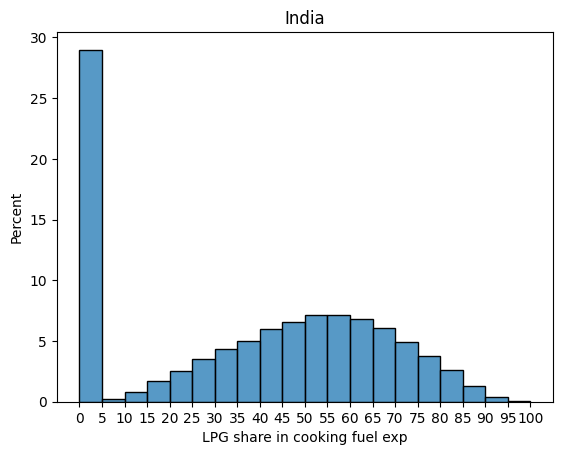

In [372]:
sns.histplot(x = df['share_lpg'], weights = df['multiplier']/100, stat = 'percent', binwidth= 5)
plt.title('India')
plt.xlabel('LPG share in cooking fuel exp')
plt.xticks(np.arange(0,105,5))
plt.show()

NameError: name 'sns' is not defined

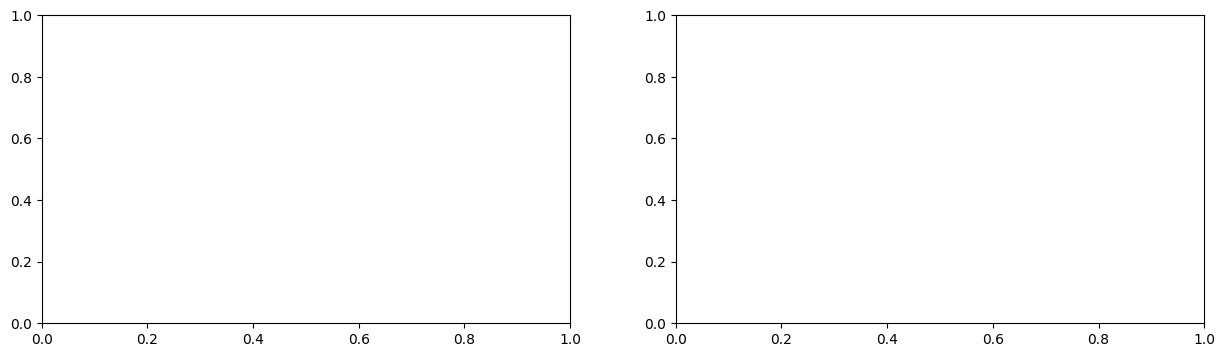

In [2]:
fig, axs = plt.subplots(1,2, figsize = (15,4))

sns.histplot(x = df.loc[df['sector'] == '1', 'share_lpg'], stat = 'percent', binwidth=5, ax = axs[0], 
             weights = df.loc[df['sector'] == '1', 'multiplier']/100)
axs[0].set_ylim(bottom=0, top=40)
axs[0].set_title('Rural')
axs[0].set_xlabel('LPG share in cooking fuel exp')
axs[0].set_xticks(ticks = np.arange(0,105,5))


sns.histplot(x = df.loc[df['sector'] == '2', 'share_lpg'], stat = 'percent', binwidth=5, ax = axs[1],
             weights = df.loc[df['sector'] == '2', 'multiplier']/100)
axs[1].set_ylim(bottom=0, top=40)
axs[1].set_title('Urban')
axs[1].set_xlabel('LPG share in cooking fuel exp')
axs[1].set_xticks(ticks = np.arange(0,105,5))

plt.show()

## HH category by LPG consumption

<Axes: xlabel='lpg_class', ylabel='Percent'>

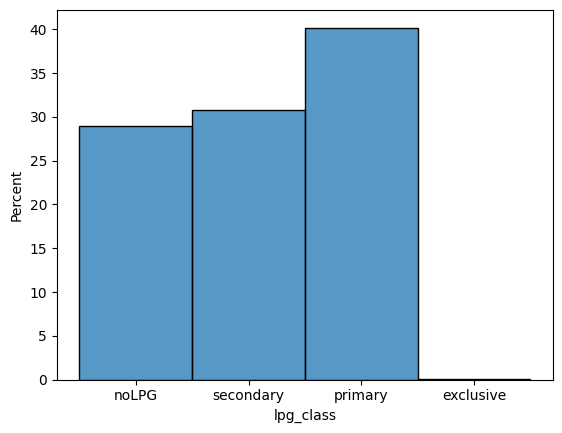

In [374]:
sns.histplot(x = df['lpg_class'],
             weights= df['multiplier']/100,
             stat = 'percent')

# Exporting

In [375]:
df.to_stata("Raw_data.dta")

C:\Users\Tarun\AppData\Local\Temp\ipykernel_18532\1014653913.py:1: InvalidColumnName: 
Not all pandas column names were valid Stata variable names.
The following replacements have been made:

    total expenditure   ->   total_expenditure

If this is not what you expect, please make sure you have Stata-compliant
column names in your DataFrame (strings only, max 32 characters, only
alphanumerics and underscores, no Stata reserved words)

  df.to_stata("Raw_data.dta")
